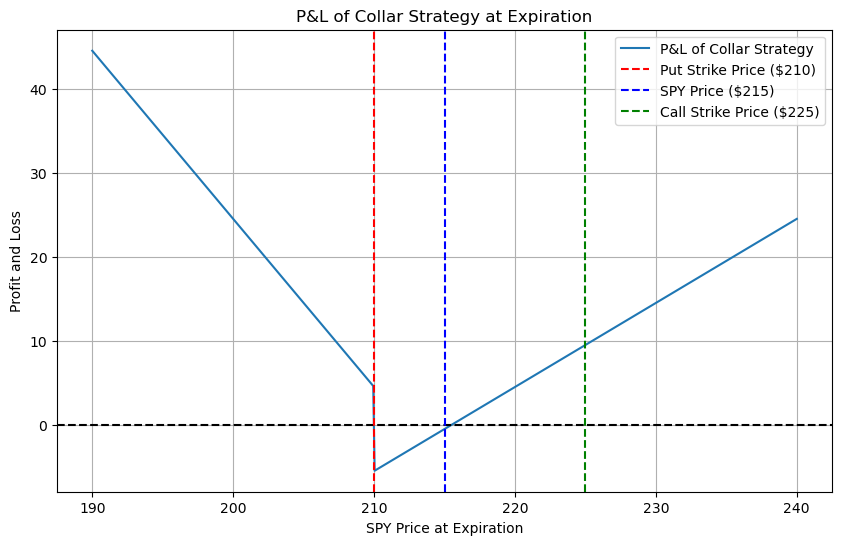

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
S0 = 215          # Current stock price
K_put = 210       # Put strike price
K_call = 225      # Call strike price
cost_of_strategy = 0.50  # Net cost per share
expiration_prices = np.linspace(190, 240, 500)  # Range of SPY prices at expiration

# Calculate P&L
def calculate_pnl(S):
    if S < K_put:
        # Loss on SPY shares - Gain on Put option
        pnl = (S0 - S) + (K_put - S) - cost_of_strategy
    elif K_put <= S <= K_call:
        # No gain/loss on Put or Call option
        pnl = (S - S0) - cost_of_strategy
    else:  # S > K_call
        # Loss on SPY shares + Gain on Call option
        pnl = (K_call - S0) + (S - K_call) - cost_of_strategy
    return pnl

# Compute P&L for the range of SPY prices
pnl = np.array([calculate_pnl(S) for S in expiration_prices])

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(expiration_prices, pnl, label='P&L of Collar Strategy')
plt.axhline(0, color='black', linestyle='--')
plt.axvline(K_put, color='red', linestyle='--', label='Put Strike Price ($210)')
plt.axvline(S0, color='blue', linestyle='--', label='SPY Price ($215)')
plt.axvline(K_call, color='green', linestyle='--', label='Call Strike Price ($225)')
plt.title('P&L of Collar Strategy at Expiration')
plt.xlabel('SPY Price at Expiration')
plt.ylabel('Profit and Loss')
plt.legend()
plt.grid(True)
plt.show()